# Lattice figures plotting

This small code (to be polished) draws the different lattice geometries for the paper.

# Imports and constants

In [63]:
import numpy as np
import matplotlib.pyplot as plt

In [166]:
# Common dirs.
outdirpath_fig = "/net/debye/gmennella/randium/analysis/analysis_figure"

# Plot params.
fontsize_title = 22

# 2D

## Functions

In [167]:
def plot_square_lattice(
    Lx=5,
    Ly=5,
    ax=None,
    site_size=50,
    bond_width=1.5
):
    positions = {}


    neighbor_list = [
        (1, 0),
        (0, 1),
    ]

    # Generate sites
    for i in range(Lx):
        for j in range(Ly):
            positions[(i, j)] = np.array([i, j])

    # Draw bonds
    for i in range(Lx):
        for j in range(Ly):

            for di, dj in neighbor_list:

                ni = i + di
                nj = j + dj

                if 0 <= ni < Lx and 0 <= nj < Ly:

                    p1 = positions[(i, j)]
                    p2 = positions[(ni, nj)]

                    ax.plot(
                        [p1[0], p2[0]],
                        [p1[1], p2[1]],
                        lw=bond_width,
                        zorder=1
                    )

    coords = np.array(list(positions.values()))

    # ================================================================
    # DRAW SITES
    # ================================================================
    
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=site_size,
        zorder=2
    )

    ax.set_aspect("equal")
    ax.axis("off")

    return ax

In [168]:
def plot_king_lattice(
    Lx=5,
    Ly=5,
    ax=None,
    site_size=50,
    bond_width=1.5
):
    positions = {}

    neighbor_list = [
        (1, 0),
        (0, 1),
        (1, 1),
        (1, -1),
    ]

    # Generate sites
    for i in range(Lx):
        for j in range(Ly):
            positions[(i, j)] = np.array([i, j])

    # Draw bonds
    for i in range(Lx):
        for j in range(Ly):

            for di, dj in neighbor_list:

                ni = i + di
                nj = j + dj

                if 0 <= ni < Lx and 0 <= nj < Ly:

                    p1 = positions[(i, j)]
                    p2 = positions[(ni, nj)]

                    ax.plot(
                        [p1[0], p2[0]],
                        [p1[1], p2[1]],
                        lw=bond_width,
                        zorder=1
                    )

    coords = np.array(list(positions.values()))

    # ================================================================
    # DRAW SITES
    # ================================================================
    
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=site_size,
        zorder=2
    )

    ax.set_aspect("equal")
    ax.axis("off")

    return ax

In [169]:
def plot_triangular_lattice(
    Lx=5,
    Ly=5,
    ax=None,
    site_size=50,
    bond_width=1.5
):

    positions = {}
    
    # Generate sites on a rectangular grid
    for i in range(Lx):
        for j in range(Ly):
            positions[(i, j)] = np.array([i, j])

    # Draw bonds
    for i in range(Lx):
        for j in range(Ly):

            p1 = positions[(i, j)]

            # Horizontal bond
            if i + 1 < Lx:

                p2 = positions[(i + 1, j)]

                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    lw=bond_width,
                    zorder=1
                )

            # Vertical bond
            if j + 1 < Ly:

                p2 = positions[(i, j + 1)]

                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    lw=bond_width,
                    zorder=1
                )

           # Diagonal bond: top-left to bottom-right
            if i + 1 < Lx and j - 1 >= 0:

                p2 = positions[(i + 1, j - 1)]

                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    lw=bond_width,
                    zorder=1
                )

    coords = np.array(list(positions.values()))

    # ================================================================
    # DRAW SITES
    # ================================================================

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=site_size,
        zorder=2
    )

    ax.set_aspect("equal")
    ax.axis("off")

    return ax

In [170]:
def plot_hexagonal_lattice(
    Lx=5,
    Ly=5,
    ax=None,
    site_size=50,
    bond_width=1.5
):

    a = 1.0

    positions_A = {}
    positions_B = {}

    # ================================================================
    # HONEYCOMB GEOMETRY
    # ================================================================

    a1 = np.array([
        np.sqrt(3) * a,
        0.0
    ])

    a2 = np.array([
        np.sqrt(3) / 2 * a,
        3.0 / 2 * a
    ])

    # Offset from A to B
    delta = np.array([
        np.sqrt(3) / 2 * a,
        0.5 * a
    ])

    # ================================================================
    # GENERATE SITES
    #
    # Extend the lattice by one extra row and one extra site
    # on each horizontal boundary.
    # ================================================================

    for j in range(Ly + 1):

        i_min = int(np.ceil(-j / 2)) - 1
        i_max = int(np.floor((2 * Lx - j) / 2)) + 1

        for i in range(i_min, i_max + 1):

            R = i * a1 + j * a2

            positions_A[(i, j)] = R
            positions_B[(i, j)] = R + delta

    # ================================================================
    # DRAW BONDS
    # ================================================================

    for (i, j), pA in positions_A.items():

        # Bond 1: A(i,j) -> B(i,j)
        if (i, j) in positions_B:

            pB = positions_B[(i, j)]

            ax.plot(
                [pA[0], pB[0]],
                [pA[1], pB[1]],
                lw=bond_width,
                zorder=1
            )

        # Bond 2: A(i,j) -> B(i-1,j)
        if (i - 1, j) in positions_B:

            pB = positions_B[(i - 1, j)]

            ax.plot(
                [pA[0], pB[0]],
                [pA[1], pB[1]],
                lw=bond_width,
                zorder=1
            )

        # Bond 3: A(i,j) -> B(i,j-1)
        if (i, j - 1) in positions_B:

            pB = positions_B[(i, j - 1)]

            ax.plot(
                [pA[0], pB[0]],
                [pA[1], pB[1]],
                lw=bond_width,
                zorder=1
            )

    # ================================================================
    # DRAW SITES
    # ================================================================

    coords_A = np.array(list(positions_A.values()))
    coords_B = np.array(list(positions_B.values()))

    coords = np.vstack([
        coords_A,
        coords_B
    ])

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=site_size,
        zorder=2
    )

    ax.set_aspect("equal")
    ax.axis("off")

    return ax

## Plots

### Test plot

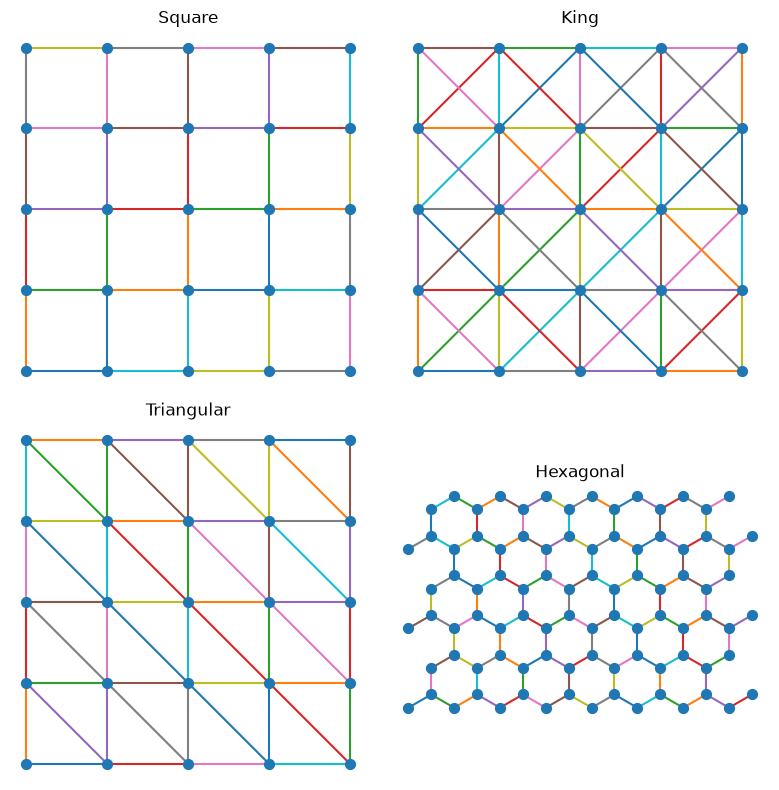

In [171]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

plot_square_lattice(Lx=5, Ly=5, ax=axes[0, 0])
plot_king_lattice(Lx=5, Ly=5, ax=axes[0, 1])
plot_triangular_lattice(Lx=5, Ly=5, ax=axes[1, 0])
plot_hexagonal_lattice(Lx=5, Ly=5, ax=axes[1, 1])

axes[0, 0].set_title("Square")
axes[0, 1].set_title("King")
axes[1, 0].set_title("Triangular")
axes[1, 1].set_title("Hexagonal")

plt.tight_layout()
plt.show()

### Square lattice

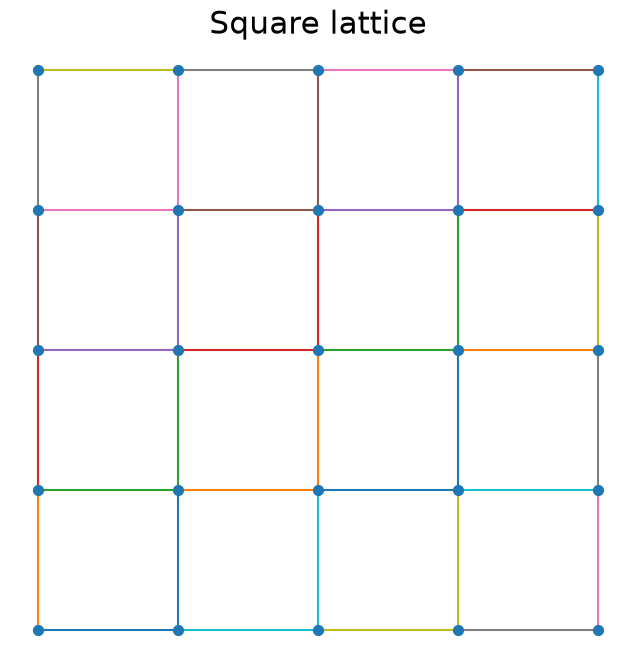

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

plot_square_lattice(Lx=5, Ly=5, ax=ax)

ax.set_title("Square lattice", fontsize=fontsize_title)

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_square_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

### Hexagonal lattice

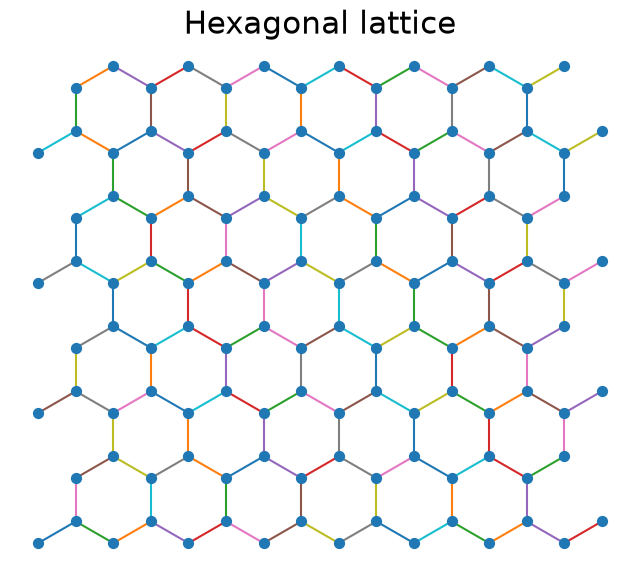

In [173]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

plot_hexagonal_lattice(Lx=5, Ly=7, ax=ax)

ax.set_title("Hexagonal lattice", fontsize=fontsize_title)

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_hexagonal_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

### Triangular

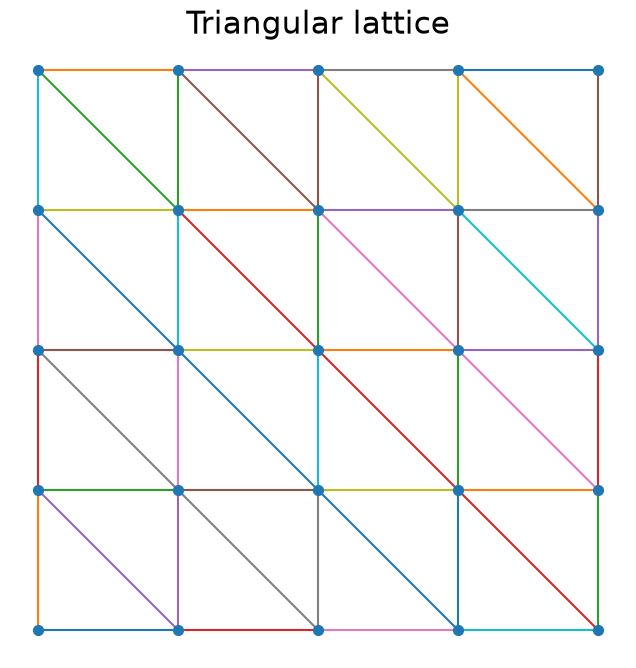

In [174]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

plot_triangular_lattice(Lx=5, Ly=5, ax=ax)

ax.set_title("Triangular lattice", fontsize=fontsize_title)

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_triangular_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

### King

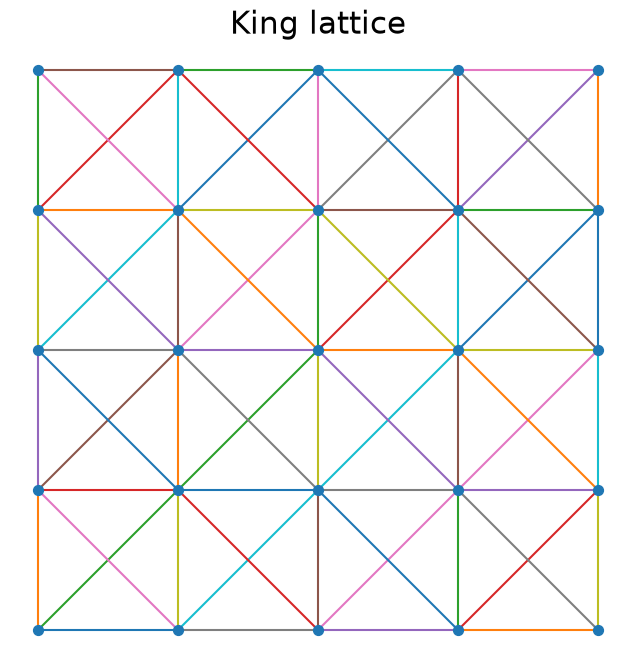

In [175]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))

plot_king_lattice(Lx=5, Ly=5, ax=ax)

ax.set_title("King lattice", fontsize=fontsize_title)

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_king_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

# 3D

## Functions

In [86]:
def plot_simple_cubic_lattice(
    Lx=5,
    Ly=5,
    Lz=5,
    ax=None,
    site_size=50,
    bond_width=1.5,
    elevation=45,
    azimuth=45
):
    """
    Plot a 3D simple cubic lattice.

    Parameters
    ----------
    Lx, Ly, Lz : int
        Number of lattice sites along x, y, and z.

    ax : matplotlib 3D axis, optional
        Axis on which to draw the lattice.

    site_size : float
        Size of the lattice-site markers.

    bond_width : float
        Width of the bonds.

    elevation : float
        Camera elevation angle in degrees.

    azimuth : float
        Camera azimuth angle in degrees.
    """

    # Create a 3D axis if none is provided
    if ax is None:

        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")

    positions = {}

    # ================================================================
    # GENERATE SITES
    # ================================================================

    for i in range(Lx):
        for j in range(Ly):
            for k in range(Lz):

                positions[(i, j, k)] = np.array([
                    i,
                    j,
                    k
                ])

    # ================================================================
    # DRAW BONDS
    # ================================================================

    for i in range(Lx):
        for j in range(Ly):
            for k in range(Lz):

                p1 = positions[(i, j, k)]

                # Bond along x
                if i + 1 < Lx:

                    p2 = positions[(i + 1, j, k)]

                    ax.plot(
                        [p1[0], p2[0]],
                        [p1[1], p2[1]],
                        [p1[2], p2[2]],
                        lw=bond_width,
                        zorder=1
                    )

                # Bond along y
                if j + 1 < Ly:

                    p2 = positions[(i, j + 1, k)]

                    ax.plot(
                        [p1[0], p2[0]],
                        [p1[1], p2[1]],
                        [p1[2], p2[2]],
                        lw=bond_width,
                        zorder=1
                    )

                # Bond along z
                if k + 1 < Lz:

                    p2 = positions[(i, j, k + 1)]

                    ax.plot(
                        [p1[0], p2[0]],
                        [p1[1], p2[1]],
                        [p1[2], p2[2]],
                        lw=bond_width,
                        zorder=1
                    )

    # ================================================================
    # DRAW SITES
    # ================================================================

    coords = np.array(list(positions.values()))

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        s=site_size,
        zorder=2
    )

    # ================================================================
    # CAMERA AND APPEARANCE
    # ================================================================

    ax.view_init(
        elev=elevation,
        azim=azimuth
    )

    ax.set_box_aspect([
        Lx - 1,
        Ly - 1,
        Lz - 1
    ])

    ax.axis("off")

    return ax

In [162]:
def plot_layered_hexagonal_lattice_v1(
    Lx=5,
    Ly=5,
    Lz=3,
    ax=None,
    site_size=50,
    bond_width=1.5,
    layer_spacing=1.0,
):

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")

    a = 1.0

    # ================================================================
    # HONEYCOMB GEOMETRY
    # ================================================================

    a1 = np.array([
        np.sqrt(3) * a,
        0.0
    ])

    a2 = np.array([
        np.sqrt(3) / 2 * a,
        3.0 / 2 * a
    ])

    delta = np.array([
        np.sqrt(3) / 2 * a,
        0.5 * a
    ])

    # ================================================================
    # STORE ALL LAYERS
    # ================================================================

    positions_A_layers = []
    positions_B_layers = []

    # ================================================================
    # GENERATE AND DRAW LAYERS
    # ================================================================

    for k in range(Lz):

        z = k * layer_spacing

        positions_A = {}
        positions_B = {}

        # ------------------------------------------------------------
        # Generate one honeycomb layer
        # ------------------------------------------------------------

        for j in range(Ly + 1):

            i_min = int(np.ceil(-j / 2)) - 1
            i_max = int(np.floor((2 * Lx - j) / 2)) + 1

            for i in range(i_min, i_max + 1):

                R = i * a1 + j * a2

                positions_A[(i, j)] = np.array([
                    R[0],
                    R[1],
                    z
                ])

                positions_B[(i, j)] = np.array([
                    R[0] + delta[0],
                    R[1] + delta[1],
                    z
                ])

        # ------------------------------------------------------------
        # Store layer
        # ------------------------------------------------------------

        positions_A_layers.append(positions_A)
        positions_B_layers.append(positions_B)

        # ------------------------------------------------------------
        # Draw bonds inside this layer
        # ------------------------------------------------------------

        for (i, j), pA in positions_A.items():

            # Bond 1: A(i,j) -> B(i,j)
            if (i, j) in positions_B:

                pB = positions_B[(i, j)]

                ax.plot(
                    [pA[0], pB[0]],
                    [pA[1], pB[1]],
                    [pA[2], pB[2]],
                    lw=bond_width,
                    color="black",
                    zorder=1
                )

            # Bond 2: A(i,j) -> B(i-1,j)
            if (i - 1, j) in positions_B:

                pB = positions_B[(i - 1, j)]

                ax.plot(
                    [pA[0], pB[0]],
                    [pA[1], pB[1]],
                    [pA[2], pB[2]],
                    lw=bond_width,
                    color="black",
                    zorder=1
                )

            # Bond 3: A(i,j) -> B(i,j-1)
            if (i, j - 1) in positions_B:

                pB = positions_B[(i, j - 1)]

                ax.plot(
                    [pA[0], pB[0]],
                    [pA[1], pB[1]],
                    [pA[2], pB[2]],
                    lw=bond_width,
                    color="black",
                    zorder=1
                )

        # ------------------------------------------------------------
        # Draw sites
        # ------------------------------------------------------------

        coords_A = np.array(list(positions_A.values()))
        coords_B = np.array(list(positions_B.values()))

        coords = np.vstack([
            coords_A,
            coords_B
        ])

        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            coords[:, 2],
            s=site_size,
            color="black",
            zorder=2
        )

    # ================================================================
    # DRAW VERTICAL SINGLE LINKS
    # ================================================================

    for k in range(Lz):

        layer_A = positions_A_layers[k]
        layer_B = positions_B_layers[k]

        # ------------------------------------------------------------
        # A and B sites
        # ------------------------------------------------------------

        for sublattice, layer in enumerate([layer_A, layer_B]):

            for (i, j), p in layer.items():

                # ----------------------------------------------------
                # 3D parity determines whether the link goes up/down
                # ----------------------------------------------------

                direction_parity = (i + j + sublattice + k) % 2

                # ----------------------------------------------------
                # 2D parity determines the colour
                # ----------------------------------------------------

                color_parity = (i + j + sublattice) % 2

                color = "green" if color_parity == 0 else "red"

                # ----------------------------------------------------
                # Even parity: connect upward
                # ----------------------------------------------------

                if direction_parity == 0 and k < Lz - 1:

                    p_next = (
                        positions_A_layers[k + 1][(i, j)]
                        if sublattice == 0
                        else positions_B_layers[k + 1][(i, j)]
                    )

                    ax.plot(
                        [p[0], p_next[0]],
                        [p[1], p_next[1]],
                        [p[2], p_next[2]],
                        lw=bond_width,
                        color=color,
                        zorder=1
                    )

                # ----------------------------------------------------
                # Odd parity: connect downward
                # ----------------------------------------------------

                elif direction_parity == 1 and k > 0:

                    p_prev = (
                        positions_A_layers[k - 1][(i, j)]
                        if sublattice == 0
                        else positions_B_layers[k - 1][(i, j)]
                    )

                    ax.plot(
                        [p[0], p_prev[0]],
                        [p[1], p_prev[1]],
                        [p[2], p_prev[2]],
                        lw=bond_width,
                        color=color,
                        zorder=1
                    )

    # ================================================================
    # AXIS / VIEW
    # ================================================================

    all_coords = np.concatenate([
        np.array(list(layer.values()))
        for layer in positions_A_layers + positions_B_layers
    ])

    x_extent = np.ptp(all_coords[:, 0])
    y_extent = np.ptp(all_coords[:, 1])
    z_extent = np.ptp(all_coords[:, 2])

    ax.set_box_aspect((
        x_extent,
        y_extent,
        z_extent
    ))

    ax.axis("off")

    return ax

In [183]:
def plot_layered_hexagonal_lattice(
    Lx=5,
    Ly=5,
    Lz=3,
    ax=None,
    site_size=50,
    bond_width=1.5,
    layer_spacing=1.0,
):

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")

    a = 1.0

    a1 = np.array([np.sqrt(3) * a, 0.0])
    a2 = np.array([np.sqrt(3) / 2 * a, 3.0 / 2 * a])
    delta = np.array([np.sqrt(3) / 2 * a, 0.5 * a])

    UP_COLOR = "red"      # sublattice A
    DOWN_COLOR = "green"  # sublattice B

    positions_A_layers = []
    positions_B_layers = []

    for k in range(Lz):

        z = k * layer_spacing
        positions_A = {}
        positions_B = {}

        for j in range(Ly + 1):
            i_min = int(np.ceil(-j / 2)) - 1
            i_max = int(np.floor((2 * Lx - j) / 2)) + 1
            for i in range(i_min, i_max + 1):
                R = i * a1 + j * a2
                positions_A[(i, j)] = np.array([R[0], R[1], z])
                positions_B[(i, j)] = np.array([R[0] + delta[0], R[1] + delta[1], z])

        positions_A_layers.append(positions_A)
        positions_B_layers.append(positions_B)

        # in-layer bonds -- unchanged, matches 2D reference (no explicit color)
        for (i, j), pA in positions_A.items():

            if (i, j) in positions_B:
                pB = positions_B[(i, j)]
                ax.plot([pA[0], pB[0]], [pA[1], pB[1]], [pA[2], pB[2]],
                        lw=bond_width, zorder=1)

            if (i - 1, j) in positions_B:
                pB = positions_B[(i - 1, j)]
                ax.plot([pA[0], pB[0]], [pA[1], pB[1]], [pA[2], pB[2]],
                        lw=bond_width, zorder=1)

            if (i, j - 1) in positions_B:
                pB = positions_B[(i, j - 1)]
                ax.plot([pA[0], pB[0]], [pA[1], pB[1]], [pA[2], pB[2]],
                        lw=bond_width, zorder=1)

        coords = np.vstack([
            np.array(list(positions_A.values())),
            np.array(list(positions_B.values())),
        ])
        ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                   s=site_size, zorder=2)

    # ================================================================
    # VERTICAL SINGLE LINKS
    #
    # Direction/color is tied to SUBLATTICE, not to (i+j). Since every
    # in-plane bond connects A to B (honeycomb is bipartite), this
    # guarantees every pair of in-plane neighbors gets opposite
    # colors -- no extra i,j-dependent parity needed.
    #
    # "Single link per site" still holds: sublattice A always launches
    # from even-index layers (0->1, 2->3, ...), sublattice B always
    # launches from odd-index layers (1->2, 3->4, ...). Each site
    # therefore has at most one vertical neighbor; consecutive layer
    # pairs are covered exactly once, with no duplicate draws.
    # ================================================================

    for k in range(Lz - 1):

        # sublattice 0 (A) launches at even k, sublattice 1 (B) at odd k
        launching_sublattice = k % 2
        color = UP_COLOR if launching_sublattice == 0 else DOWN_COLOR

        layer = positions_A_layers[k] if launching_sublattice == 0 else positions_B_layers[k]
        layer_next = (
            positions_A_layers[k + 1] if launching_sublattice == 0
            else positions_B_layers[k + 1]
        )

        for (i, j), p in layer.items():

            p_next = layer_next[(i, j)]

            ax.plot(
                [p[0], p_next[0]],
                [p[1], p_next[1]],
                [p[2], p_next[2]],
                lw=bond_width,
                color=color,
                zorder=1,
            )

    all_coords = np.concatenate([
        np.array(list(layer.values()))
        for layer in positions_A_layers + positions_B_layers
    ])

    x_extent = np.ptp(all_coords[:, 0])
    y_extent = np.ptp(all_coords[:, 1])
    z_extent = np.ptp(all_coords[:, 2])

    ax.set_box_aspect((x_extent, y_extent, z_extent))
    ax.axis("off")

    return ax

## Plots

### Test plots

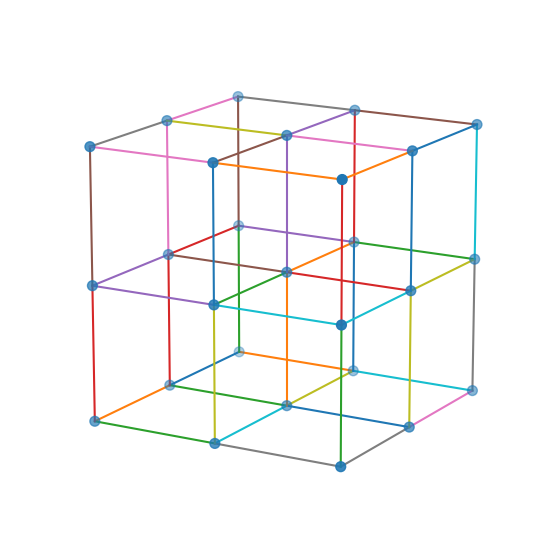

In [184]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

plot_simple_cubic_lattice(
    Lx=3,
    Ly=3,
    Lz=3,
    ax=ax,
    elevation=15,
    azimuth=30
)

plt.show()

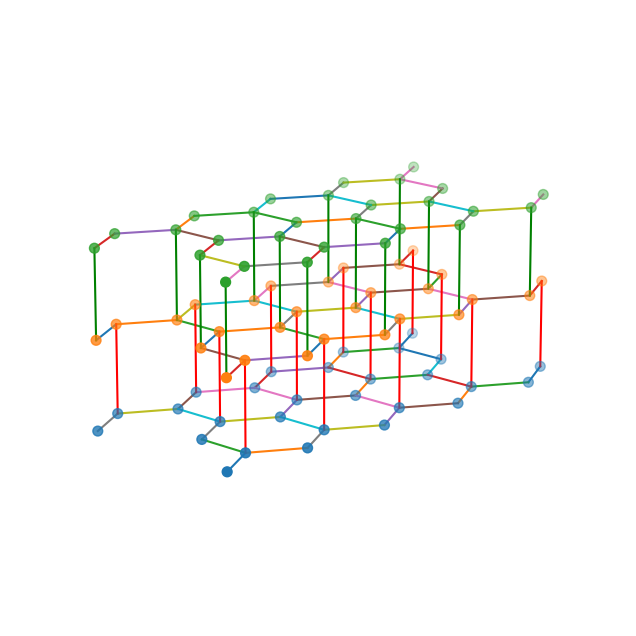

In [195]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

plot_layered_hexagonal_lattice(
    Lx=2,
    Ly=2,
    Lz=3,
    ax=ax,
    layer_spacing=1.5,
)

ax.view_init(elev=15, azim=45)

plt.show()

### Simple cubic

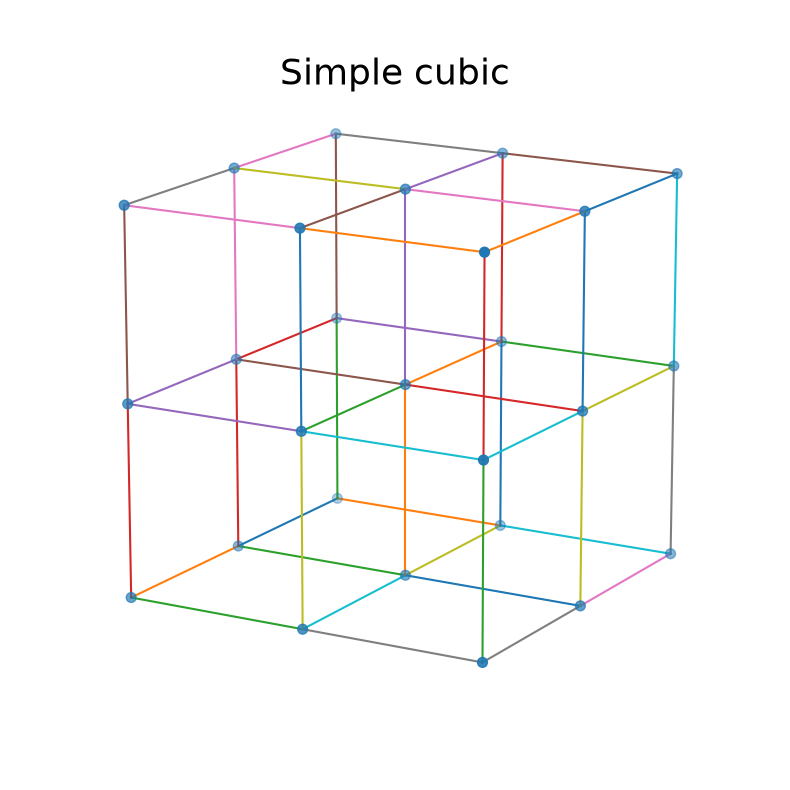

In [205]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

plot_simple_cubic_lattice(
    Lx=3,
    Ly=3,
    Lz=3,
    ax=ax,
    elevation=15,
    azimuth=30
)

ax.set_title(
    "Simple cubic", 
    fontsize=fontsize_title+4,
    y=0.97
)


plt.tight_layout()
# plt.show()

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_simple_cubic_lattice.png",
    dpi=300,
    bbox_inches="tight"
)

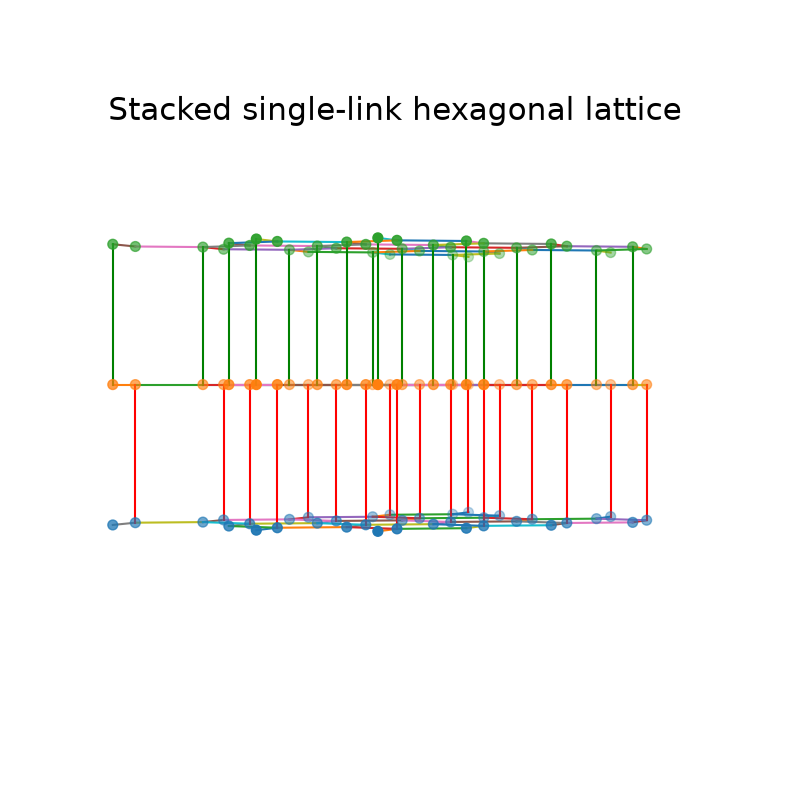

In [203]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

plot_layered_hexagonal_lattice(
    Lx=2,
    Ly=3,
    Lz=3,
    ax=ax,
    layer_spacing=2,
)

ax.view_init(elev=0, azim=45)

ax.set_title(
    "Stacked single-link hexagonal lattice", 
    fontsize=fontsize_title,
    y=0.92
)


plt.tight_layout()
# plt.show()

plt.savefig(
    fname=f"{outdirpath_fig}/diagram_stacked_single_link_hexagonal_lattice_flat.png",
    dpi=300,
    bbox_inches="tight"
)